# MLDU-E -- PGA vs published unlearning baselines on Pythia-70M

Compares **PGA** against four behavioural baselines (**GA**, **NPO**, **RMU**, **IDK**) plus the **adversarial-PGA** variant when its capability JSON is provided.

**Three standalone figures** (each one: bigger bar = better):
- **Figure 1: Representational erasure** -- per-layer probe defeat (1 - probe accuracy). Higher curve = stronger erasure.
- **Figure 2: Behavioural suppression** -- recall drop magnitude (|delta recall logP| from baseline). Higher bar = stronger suppression.
- **Figure 3: Capability retention** -- baseline PPL / method PPL. Higher bar = capability preserved better.

**Inputs auto-discovered under `./data/`, `/kaggle/working/`, or `/kaggle/input/<any-dataset>/`:**
- `pythia_memorized.json`, `pythia_clean.json`  (memorised + paired clean prefixes)
- `heldout.json`  (held-out PPL pool)
- LoRA adapter folder containing `adapter_config.json` + `adapter_model.safetensors` (the trained PGA)
- (optional) `mldu_e_capability_benchmarks.json` and `mldu_e_capability_benchmarks_adversarial.json` -- if present, a 4th figure compares lm-eval benchmark accuracy

## 1. Setup

In [26]:
import os, sys, json, time, copy, subprocess
def _v(p):
    try: from importlib.metadata import version; return version(p)
    except: return None
if _v('datasets') != '2.21.0':
    subprocess.check_call([sys.executable,'-m','pip','install','-q','datasets==2.21.0'])

import torch, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from pathlib import Path

## 2. Configuration

In [27]:
# ---- paths (auto-discover under any of these roots) ----
DATA_ROOTS = ['./data', './reproducibility/data', '/kaggle/working', '/kaggle/input']
OUT_DIR    = Path('/kaggle/working' if Path('/kaggle/working').exists() else '.')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- model + probe constants ----
MODEL_NAME    = 'EleutherAI/pythia-70m'
MAX_LEN       = 128
N_HIDDEN      = 7         # residual depths (embed + 6 transformer layers)
PROBE_LAYER   = 4
PROBE_C       = 1.0

# ---- per-method constants for the unified rerun ----
RMU_LAYER     = 3
IDK_TARGET    = "I don't know."

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'OUT_DIR    = {OUT_DIR.resolve()}')
print(f'DATA_ROOTS = {DATA_ROOTS}')
print(f'DEVICE     = {DEVICE}')

OUT_DIR    = /kaggle/working
DATA_ROOTS = ['./data', './reproducibility/data', '/kaggle/working', '/kaggle/input']
DEVICE     = cuda


## 3. Locate input files (recursive auto-discovery)

In [28]:
import glob

def find_file(fname, roots=DATA_ROOTS):
    """Return the first matching path for `fname` under any of `roots` (recursive). None if not found."""
    for root in roots:
        if not Path(root).exists(): continue
        matches = glob.glob(f'{root}/**/{fname}', recursive=True)
        if matches: return Path(matches[0])
    return None

def find_dir_with(*required_files, roots=DATA_ROOTS):
    """Return first folder containing ALL `required_files` under any root."""
    for root in roots:
        if not Path(root).exists(): continue
        for cfg in glob.glob(f'{root}/**/{required_files[0]}', recursive=True):
            d = Path(cfg).parent
            if all((d / f).exists() for f in required_files):
                return d
    return None

# Sanity-check inputs
required = ['pythia_memorized.json', 'pythia_clean.json', 'heldout.json']
optional = ['mldu_e_capability_benchmarks.json', 'mldu_e_capability_benchmarks_adversarial.json']

print('Required files:')
for fn in required:
    p = find_file(fn)
    status = str(p) if p else 'NOT FOUND -- attach the dataset!'
    print(f'  {fn:50s} -> {status}')

print('\nOptional files (capability benchmarks):')
for fn in optional:
    p = find_file(fn)
    status = str(p) if p else 'not found (will skip Figure 4)'
    print(f'  {fn:50s} -> {status}')

print('\nLoRA dir:')
lora_dir = find_dir_with('adapter_config.json', 'adapter_model.safetensors')
print(f'  PGA LoRA -> {lora_dir if lora_dir else "NOT FOUND -- PGA panel will be skipped"}')

Required files:
  pythia_memorized.json                              -> /kaggle/input/datasets/<anonymous>/newdatajson/pythia_memorized.json
  pythia_clean.json                                  -> /kaggle/input/datasets/<anonymous>/newdatajson/pythia_clean.json
  heldout.json                                       -> /kaggle/input/datasets/<anonymous>/heldout/heldout.json

Optional files (capability benchmarks):
  mldu_e_capability_benchmarks.json                  -> /kaggle/input/datasets/<anonymous>/benchmark/mldu_e_capability_benchmarks.json
  mldu_e_capability_benchmarks_adversarial.json      -> /kaggle/input/datasets/<anonymous>/benchmark/mldu_e_capability_benchmarks_adversarial.json

LoRA dir:
  PGA LoRA -> /kaggle/input/datasets/<anonymous>/loradata/pythia70m_pga_lora


## 4. Load Pythia-70M and the memorised / clean prefix pools

In [29]:
print(f'Loading {MODEL_NAME}...')
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token is None: tok.pad_token = tok.eos_token
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32).to(DEVICE)
base.eval()

mem_path   = find_file('pythia_memorized.json')
clean_path = find_file('pythia_clean.json')
if not (mem_path and clean_path):
    raise FileNotFoundError('pythia_memorized.json / pythia_clean.json not found in any DATA_ROOTS folder.')

MEM   = json.load(open(mem_path))
CLEAN = json.load(open(clean_path))
N = len(MEM)
print(f'  loaded MEM  ({N} sequences) from {mem_path}')
print(f'  loaded CLEAN ({len(CLEAN)} sequences) from {clean_path}')

Loading EleutherAI/pythia-70m...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  loaded MEM  (7 sequences) from /kaggle/input/datasets/<anonymous>/newdatajson/pythia_memorized.json
  loaded CLEAN (7 sequences) from /kaggle/input/datasets/<anonymous>/newdatajson/pythia_clean.json


## 5. Probe / recall / PPL helpers and baseline metrics

In [30]:
@torch.no_grad()
def acts_at_layer(m, texts, L):
    m.eval(); out = []
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        out.append(m(**e, output_hidden_states=True).hidden_states[L][0,-1,:].cpu().numpy())
    return np.array(out)

def loo_probe(X, Y, seed=42):
    n = len(Y); ok = 0
    for i in range(n):
        msk = np.ones(n, bool); msk[i] = False
        sc  = StandardScaler().fit(X[msk])
        clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=seed).fit(sc.transform(X[msk]), Y[msk])
        ok += int(clf.predict(sc.transform(X[i:i+1]))[0] == Y[i])
    return ok / n

@torch.no_grad()
def compute_recall(m, texts):
    m.eval(); v = []
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        v.append(-float(m(**e, labels=e['input_ids']).loss.item()))
    return float(np.mean(v))

@torch.no_grad()
def compute_ppl(m, texts):
    m.eval(); v = []
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        v.append(float(np.exp(m(**e, labels=e['input_ids']).loss.item())))
    return float(np.mean(v))

def per_layer_probe(m, ALL, Y):
    return {L: loo_probe(acts_at_layer(m, ALL, L), Y) for L in range(N_HIDDEN)}

# --- held-out pool (REQUIRED) ---
heldout_path = find_file('heldout.json')
if heldout_path is None:
    raise FileNotFoundError('heldout.json not found. Provide a JSON list of natural-text strings.')
HELD_OUT = json.load(open(heldout_path))
print(f'loaded {len(HELD_OUT)} held-out prompts from {heldout_path}')

ALL = MEM + CLEAN
Y   = np.array([1]*N + [0]*N)

print('\n=== BASELINE (untreated Pythia-70M) ===')
baseline_pre    = per_layer_probe(base, ALL, Y)
baseline_recall = compute_recall(base, MEM)
baseline_ppl    = compute_ppl(base, HELD_OUT)
for L, v in baseline_pre.items(): print(f'  L{L}: probe={v:.3f}')
print(f'  recall={baseline_recall:.3f}  PPL={baseline_ppl:.3f}')

results = {'baseline': {'per_layer_probe': {str(k): float(v) for k,v in baseline_pre.items()},
                        'recall_logp':     float(baseline_recall),
                        'heldout_ppl':     float(baseline_ppl)}}

loaded 20 held-out prompts from /kaggle/input/datasets/<anonymous>/heldout/heldout.json

=== BASELINE (untreated Pythia-70M) ===
  L0: probe=0.643
  L1: probe=0.714
  L2: probe=0.714
  L3: probe=0.857
  L4: probe=0.857
  L5: probe=0.929
  L6: probe=0.929
  recall=-1.137  PPL=191.051


## 6. Unified head-to-head: train baselines + load PGA

All baselines trained inline with **per-method tuned hyperparameters** and a **PPL early-stop gate** at ~5.5x baseline. PGA loaded from LoRA checkpoint and re-evaluated on the same pipeline. Saves combined `mldu_e_unlearning_baselines_v2.json` to `OUT_DIR`.

In [31]:
PPL_CEIL = baseline_ppl * 5.5
EVAL_EVERY = 5

CONFIG = {
    'GA' : dict(lr=1e-5, epochs=30,                eval_every=EVAL_EVERY),
    'NPO': dict(lr=5e-6, epochs=50, beta=0.5,      eval_every=EVAL_EVERY),
    'RMU': dict(lr=5e-6, epochs=30, alpha=0.05,    eval_every=EVAL_EVERY),
    'IDK': dict(lr=5e-6, epochs=50,                eval_every=EVAL_EVERY),
}
print(f'PPL early-stop ceiling: {PPL_CEIL:.1f} (baseline={baseline_ppl:.1f})')

results_v2 = {'baseline': results['baseline']}

def evaluate_one(m):
    m.eval()
    return {'per_layer_probe': {str(k): float(v) for k,v in per_layer_probe(m,ALL,Y).items()},
            'recall_logp':     float(compute_recall(m, MEM)),
            'heldout_ppl':     float(compute_ppl(m, HELD_OUT))}

# ---- GA ----
print('\n' + '='*60 + '\n  GA  PPL-gated\n' + '='*60)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['GA']['lr'])
for ep in range(1, CONFIG['GA']['epochs']+1):
    m.train(); opt.zero_grad()
    for t in MEM:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        loss = -m(**e, labels=e['input_ids']).loss
        loss.backward()
    opt.step()
    if ep % CONFIG['GA']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT)
        print(f'  ep {ep:3d}: recall={compute_recall(m,MEM):7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL:
            print(f'  --> early-stop: PPL exceeded ceiling'); break
results_v2['GA'] = evaluate_one(m); del m, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- NPO ----
print('\n' + '='*60 + '\n  NPO  beta=0.5  PPL-gated\n' + '='*60)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
ref = copy.deepcopy(base).to(DEVICE)
for p in ref.parameters(): p.requires_grad = False
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['NPO']['lr'])
beta = CONFIG['NPO']['beta']
for ep in range(1, CONFIG['NPO']['epochs']+1):
    m.train(); opt.zero_grad()
    for t in MEM:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        lp_pi = -m(**e, labels=e['input_ids']).loss
        with torch.no_grad():
            lp_ref = -ref(**e, labels=e['input_ids']).loss.detach()
        loss = -2.0/beta * torch.nn.functional.logsigmoid(-beta * (lp_pi - lp_ref))
        loss.backward()
    opt.step()
    if ep % CONFIG['NPO']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT)
        print(f'  ep {ep:3d}: recall={compute_recall(m,MEM):7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL: print('  --> early-stop'); break
results_v2['NPO'] = evaluate_one(m); del m, ref, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- RMU ----
print('\n' + '='*60 + '\n  RMU  alpha=0.05  PPL-gated\n' + '='*60)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['RMU']['lr'])
d_model = base.config.hidden_size
random_dir = torch.randn(d_model, device=DEVICE); random_dir /= random_dir.norm()
alpha = CONFIG['RMU']['alpha']
for ep in range(1, CONFIG['RMU']['epochs']+1):
    m.train(); opt.zero_grad()
    for tm, tc in zip(MEM, CLEAN):
        em = tok(tm, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        ec = tok(tc, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        h_m = m(**em, output_hidden_states=True).hidden_states[RMU_LAYER][0,-1,:]
        out_c = m(**ec, output_hidden_states=True, labels=ec['input_ids'])
        loss = (h_m - alpha*random_dir).pow(2).mean() + out_c.loss
        loss.backward()
    opt.step()
    if ep % CONFIG['RMU']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT)
        print(f'  ep {ep:3d}: recall={compute_recall(m,MEM):7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL: print('  --> early-stop'); break
results_v2['RMU'] = evaluate_one(m); del m, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- IDK ----
print('\n' + '='*60 + '\n  IDK  PPL-gated\n' + '='*60)
torch.manual_seed(42); np.random.seed(42)
m = copy.deepcopy(base).to(DEVICE)
opt = torch.optim.Adam(m.parameters(), lr=CONFIG['IDK']['lr'])
for ep in range(1, CONFIG['IDK']['epochs']+1):
    m.train(); opt.zero_grad()
    for t in MEM:
        first_third = t[:max(20, len(t)//3)]
        full = first_third + ' ' + IDK_TARGET
        e = tok(full, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        prompt_len = tok(first_third, return_tensors='pt', truncation=True, max_length=MAX_LEN)['input_ids'].shape[1]
        labels = e['input_ids'].clone(); labels[:, :prompt_len] = -100
        loss = m(**e, labels=labels).loss
        loss.backward()
    opt.step()
    if ep % CONFIG['IDK']['eval_every'] == 0 or ep == 1:
        m.eval(); ppl_now = compute_ppl(m, HELD_OUT)
        print(f'  ep {ep:3d}: recall={compute_recall(m,MEM):7.3f}  PPL={ppl_now:.1f}')
        if ppl_now > PPL_CEIL: print('  --> early-stop'); break
results_v2['IDK'] = evaluate_one(m); del m, opt
if torch.cuda.is_available(): torch.cuda.empty_cache()

# ---- PGA: load from LoRA checkpoint ----
print('\n' + '='*60 + '\n  PGA  (LoRA loaded, re-evaluated)\n' + '='*60)
if lora_dir is not None:
    from peft import PeftModel
    pga_base  = copy.deepcopy(base).to(DEVICE)
    pga_model = PeftModel.from_pretrained(pga_base, str(lora_dir)).to(DEVICE)
    pga_model.eval()
    results_v2['PGA'] = evaluate_one(pga_model)
    print(f'  loaded LoRA from {lora_dir}')
    del pga_model, pga_base
    if torch.cuda.is_available(): torch.cuda.empty_cache()
else:
    print('  PGA LoRA not found -- skipping.')

# ---- save ----
out_path = OUT_DIR / 'mldu_e_unlearning_baselines_v2.json'
json.dump({
    'model': MODEL_NAME, 'baseline_ppl': float(baseline_ppl),
    'ppl_ceiling': float(PPL_CEIL),
    'config': {k: {kk: vv for kk, vv in v.items() if kk != 'eval_every'} for k, v in CONFIG.items()},
    'results': results_v2,
}, open(out_path, 'w'), indent=2)
print(f'\nsaved: {out_path}')

PPL early-stop ceiling: 1050.8 (baseline=191.1)

  GA  PPL-gated
  ep   1: recall= -1.583  PPL=191.1
  ep   5: recall= -5.256  PPL=207.1
  ep  10: recall=-17.176  PPL=267.2
  ep  15: recall=-40.458  PPL=618.0
  ep  20: recall=-63.353  PPL=10198.5
  --> early-stop: PPL exceeded ceiling

  NPO  beta=0.5  PPL-gated
  ep   1: recall= -1.358  PPL=190.6
  ep   5: recall= -2.411  PPL=194.2
  ep  10: recall= -5.160  PPL=206.9
  ep  15: recall= -8.970  PPL=226.8
  ep  20: recall=-12.311  PPL=255.7
  ep  25: recall=-14.870  PPL=292.3
  ep  30: recall=-16.725  PPL=334.4
  ep  35: recall=-18.047  PPL=378.5
  ep  40: recall=-18.981  PPL=420.9
  ep  45: recall=-19.644  PPL=458.8
  ep  50: recall=-20.128  PPL=491.1

  RMU  alpha=0.05  PPL-gated
  ep   1: recall= -1.126  PPL=184.8
  ep   5: recall= -1.116  PPL=168.4
  ep  10: recall= -1.111  PPL=162.7
  ep  15: recall= -1.117  PPL=171.2
  ep  20: recall= -1.126  PPL=192.2
  ep  25: recall= -1.129  PPL=228.7
  ep  30: recall= -1.155  PPL=285.3

  IDK  

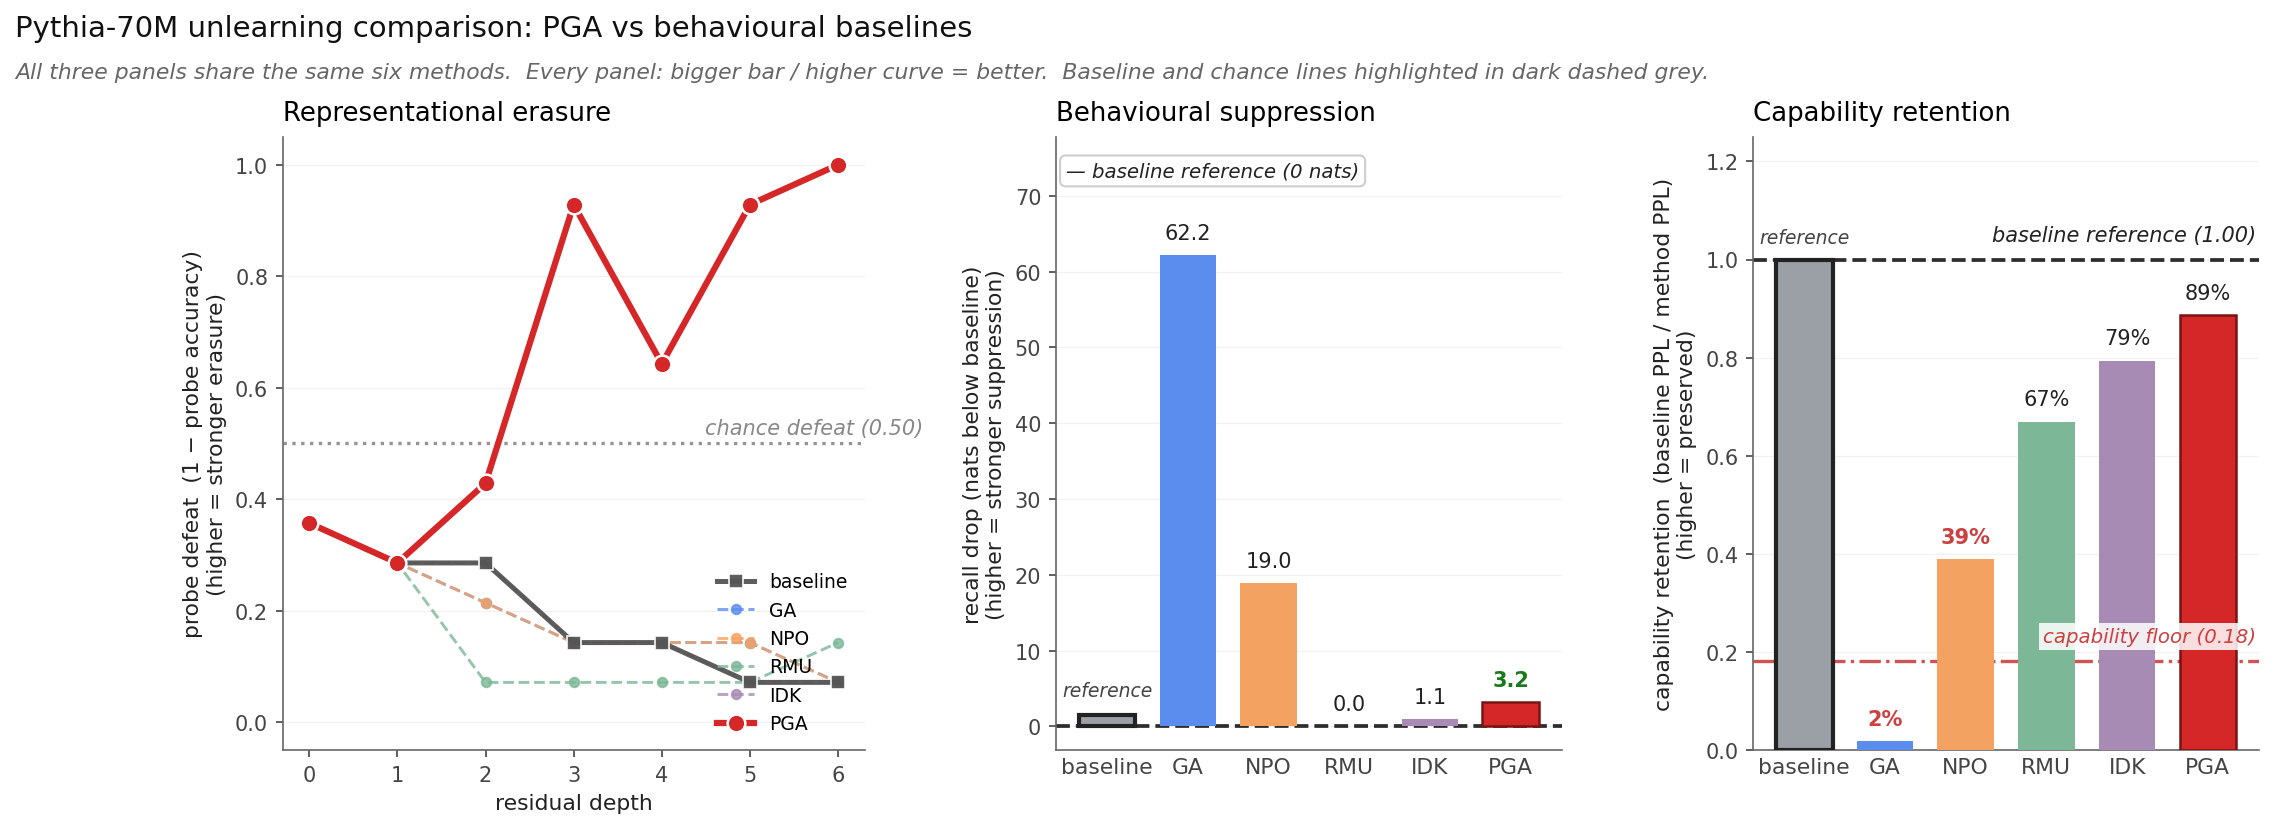

saved: /kaggle/working/fig_combined_three_metrics.png


In [47]:
# ============================================================
# Combined figure: 3 panels.  Baseline & chance references prominent.
# Every panel: bigger bar / higher curve = better.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ORDER = [m for m in ['baseline','GA','NPO','RMU','IDK','PGA'] if m in results_v2]
COLORS = {'baseline':'#9aa0a6','GA':'#5b8def','NPO':'#f4a261',
          'RMU':'#7cb798','IDK':'#a78bb5','PGA':'#d62728'}

# Reference line styling (same look across all panels)
REF_COLOR    = '#222'
REF_LINEWIDTH = 1.8
REF_LINESTYLE = '--'
REF_ALPHA     = 0.95
CHANCE_COLOR = '#888'
CHANCE_LW    = 1.6
CHANCE_LS    = ':'

plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.titlesize':12.5,'axes.labelsize':10.5,
    'xtick.labelsize':10,'ytick.labelsize':10,
    'legend.fontsize':9,'legend.frameon':False,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.edgecolor':'#666','axes.linewidth':0.8,
    'figure.facecolor':'white','axes.facecolor':'white',
    'figure.dpi':150,
})

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6),
                         gridspec_kw={'width_ratios':[1.15, 1, 1], 'wspace':0.36})

# ============================================================
# Panel 1: Representational erasure (probe defeat per layer)
# ============================================================
ax = axes[0]
depths = list(range(N_HIDDEN))

# CHANCE line first, so curves are layered above
ax.axhline(0.5, color=CHANCE_COLOR, linestyle=CHANCE_LS,
           linewidth=CHANCE_LW, alpha=0.9, zorder=2)
ax.text(N_HIDDEN-0.03, 0.51, 'chance defeat (0.50)',
        ha='right', va='bottom', fontsize=10, color=CHANCE_COLOR,
        fontweight='medium', style='italic',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))

for mt in ORDER:
    plp = results_v2[mt]['per_layer_probe']
    defeat = [1 - plp[str(L)] for L in depths]
    if mt == 'PGA':
        ax.plot(depths, defeat, marker='o', color=COLORS[mt], linestyle='-',
                linewidth=3.0, markersize=8.5, label=mt,
                markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    elif mt == 'baseline':
        # BASELINE: thick darker grey, square markers, prominent
        ax.plot(depths, defeat, marker='s', color='#555', linestyle='-',
                linewidth=2.4, markersize=7, label='baseline',
                markeredgecolor='white', markeredgewidth=0.8, zorder=4, alpha=0.95)
    else:
        ax.plot(depths, defeat, marker='o', color=COLORS[mt], linestyle='--',
                linewidth=1.4, markersize=4.5, label=mt, alpha=0.8, zorder=3)

ax.set_xlabel('residual depth')
ax.set_ylabel('probe defeat  (1 − probe accuracy)\n(higher = stronger erasure)')
ax.set_title('Representational erasure', loc='left', pad=8)
ax.set_ylim(-0.05, 1.05); ax.set_xticks(depths)
ax.grid(axis='y', alpha=0.4)
ax.legend(loc='lower right', framealpha=0.95)

# ============================================================
# Panel 2: Behavioural suppression (baseline shown as prominent reference at zero)
# ============================================================
ax = axes[1]
methods_all = list(ORDER)
base_rec = results_v2['baseline']['recall_logp']
recalls  = [results_v2[m]['recall_logp'] for m in methods_all]
suppression = [max(0, base_rec - r) for r in recalls]
xs = np.arange(len(methods_all))
bar_colors = [COLORS[m] for m in methods_all]

y_max = max(suppression) if max(suppression) > 0 else 1.0
MIN_BAR = y_max * 0.025  # 2.5% of axis height for baseline visibility

display_height = [max(s, MIN_BAR if m == 'baseline' else 0)
                  for s, m in zip(suppression, methods_all)]

# Edges: baseline + PGA both get strong outlines
edges = ['#7a1414' if m=='PGA' else ('#222' if m=='baseline' else 'none') for m in methods_all]
lws   = [1.2 if m=='PGA' else (2.0 if m=='baseline' else 0) for m in methods_all]

bars = ax.bar(xs, display_height, color=bar_colors, edgecolor=edges,
              linewidth=lws, width=0.7, zorder=3)

# NEW (label parked in top-left, no bar collision):
ax.axhline(0, color=REF_COLOR, linestyle=REF_LINESTYLE,
           linewidth=REF_LINEWIDTH, alpha=REF_ALPHA, zorder=2)
ax.text(0.02, 0.96, '— baseline reference (0 nats)',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9.5, color=REF_COLOR, fontweight='medium', style='italic',
        bbox=dict(facecolor='white', edgecolor='#ccc', alpha=0.95,
                  pad=3, boxstyle='round,pad=0.3'))

# Annotations on bars
for bar, val, mt in zip(bars, suppression, methods_all):
    x = bar.get_x() + bar.get_width()/2
    if mt == 'baseline':
        ax.text(x, MIN_BAR + y_max*0.03, 'reference',
                ha='center', va='bottom', fontsize=9, color='#444',
                fontweight='medium', style='italic')
    else:
        color = '#1a7a1a' if mt == 'PGA' else '#222'
        weight = 'bold' if mt == 'PGA' else 'medium'
        ax.text(x, val + y_max*0.025, f'{val:.1f}',
                ha='center', va='bottom', fontsize=10,
                color=color, fontweight=weight)

ax.set_xticks(xs); ax.set_xticklabels(methods_all, fontsize=10.5)
ax.set_ylabel('recall drop (nats below baseline)\n(higher = stronger suppression)')
ax.set_title('Behavioural suppression', loc='left', pad=8)
ax.set_ylim(-y_max*0.05, y_max * 1.25)
ax.grid(axis='y', alpha=0.4)
ax.tick_params(axis='x', length=0)

# ============================================================
# Panel 3: Capability retention (baseline at 1.0 + prominent reference line)
# ============================================================
ax = axes[2]
ppls = [results_v2[m]['heldout_ppl'] for m in methods_all]
retention = [baseline_ppl / p for p in ppls]
floor = baseline_ppl / PPL_CEIL

edges3 = ['#7a1414' if m=='PGA' else ('#222' if m=='baseline' else 'none') for m in methods_all]
lws3   = [1.2 if m=='PGA' else (2.0 if m=='baseline' else 0) for m in methods_all]

bars = ax.bar(xs, retention, color=bar_colors, edgecolor=edges3,
              linewidth=lws3, width=0.7, zorder=3)

# Prominent baseline reference line at 1.0
ax.axhline(1.0, color=REF_COLOR, linestyle=REF_LINESTYLE,
           linewidth=REF_LINEWIDTH, alpha=REF_ALPHA, zorder=2)
ax.text(len(xs)-0.4, 1.03, 'baseline reference (1.00)',
        ha='right', va='bottom', fontsize=10, color=REF_COLOR,
        fontweight='medium', style='italic',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))

# Capability floor reference
ax.axhline(floor, color='#cc4040', linestyle='-.', linewidth=1.6, alpha=0.9, zorder=2)
ax.text(len(xs)-0.4, floor + 0.03, f'capability floor ({floor:.2f})',
        ha='right', va='bottom', fontsize=9.5, color='#cc4040',
        fontweight='medium', style='italic',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2))

# Annotations on bars
for bar, mt, val, ppl in zip(bars, methods_all, retention, ppls):
    x = bar.get_x() + bar.get_width()/2
    if mt == 'baseline':
        color, weight, label = '#444', 'medium', 'reference'
        font_style = 'italic'
    else:
        if val >= 0.95:    color, weight = '#1a7a1a', 'bold'
        elif val >= 0.5:   color, weight = '#222',    'medium'
        else:              color, weight = '#cc4040', 'bold'
        label = f'{val*100:.0f}%'
        font_style = 'normal'
    ax.text(x, val + 0.025, label, ha='center', va='bottom',
            fontsize=10 if mt != 'baseline' else 9,
            color=color, fontweight=weight, style=font_style)

ax.set_xticks(xs); ax.set_xticklabels(methods_all, fontsize=10.5)
ax.set_ylabel('capability retention  (baseline PPL / method PPL)\n(higher = preserved)')
ax.set_title('Capability retention', loc='left', pad=8)
ax.set_ylim(0, max(1.25, max(retention)*1.15))
ax.grid(axis='y', alpha=0.4)
ax.tick_params(axis='x', length=0)

# ============================================================
# Title block (figure-level, no collision)
# ============================================================
plt.subplots_adjust(top=0.84)
fig.text(0.02, 0.96,
         'Pythia-70M unlearning comparison: PGA vs behavioural baselines',
         fontsize=14, fontweight='medium', color='#111')
fig.text(0.02, 0.91,
         'All three panels share the same six methods.  Every panel: bigger bar / higher curve = better.  Baseline and chance lines highlighted in dark dashed grey.',
         fontsize=10.5, color='#666', style='italic')

# ============================================================
# Save
# ============================================================
out_combined = OUT_DIR / 'fig_combined_three_metrics.png'
plt.savefig(out_combined, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'saved: {out_combined}')

loaded: /kaggle/input/datasets/<anonymous>/benchmark/mldu_e_capability_benchmarks.json
loaded: /kaggle/input/datasets/<anonymous>/benchmark/mldu_e_capability_benchmarks_adversarial.json


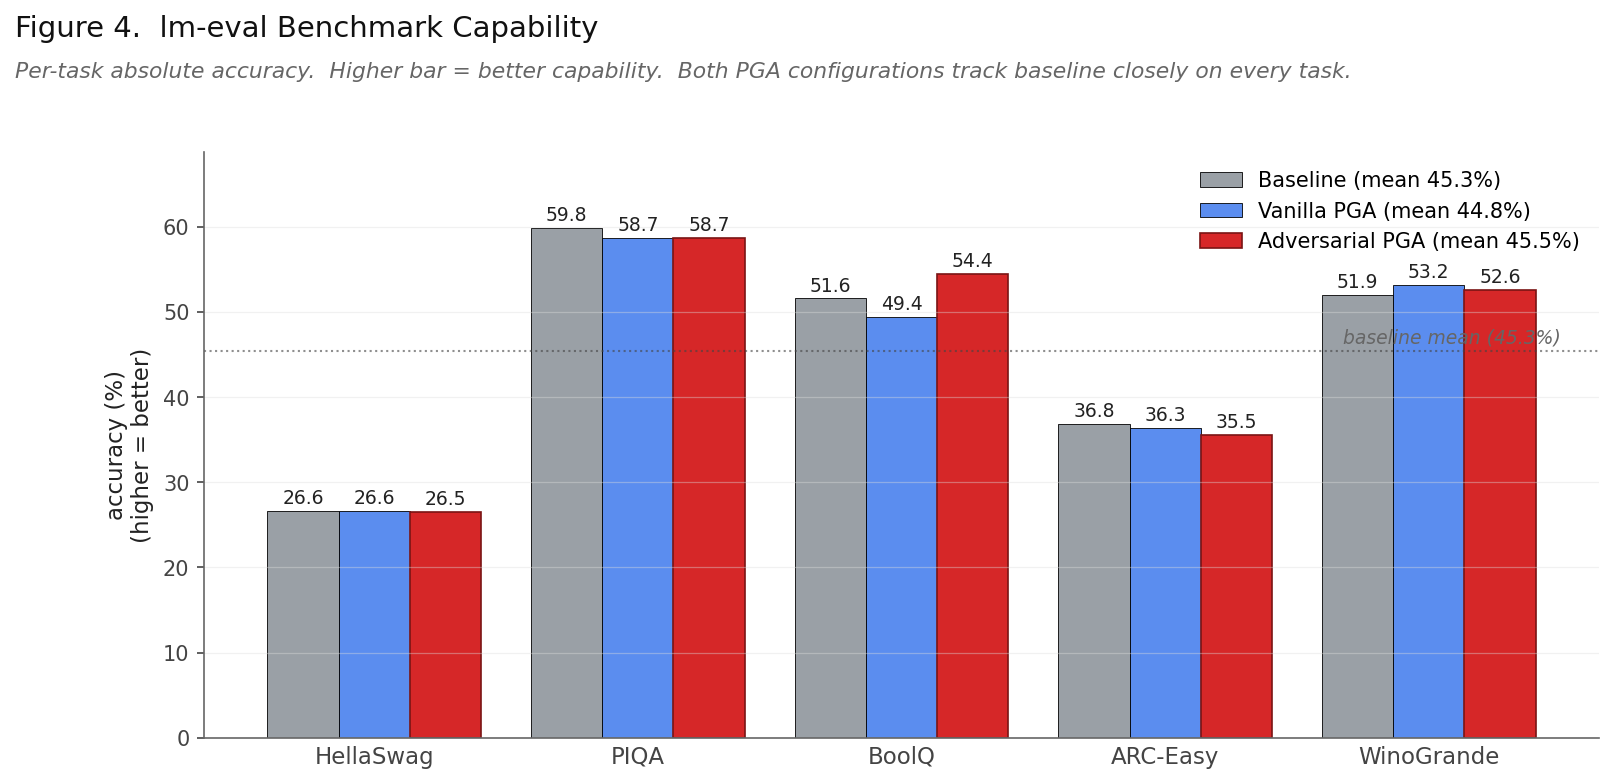

saved: /kaggle/working/fig4_benchmark_capability.png


In [44]:
# ===== Figure 4 (redesigned): per-task absolute accuracy, baseline as reference =====
cap_v_path = find_file('mldu_e_capability_benchmarks.json')
cap_a_path = find_file('mldu_e_capability_benchmarks_adversarial.json')

if cap_v_path is None or cap_a_path is None:
    print('Capability benchmark JSONs not found.  Skipping Figure 4.')
    print(f'  searched roots: {DATA_ROOTS}')
else:
    cap_v = json.load(open(cap_v_path))
    cap_a = json.load(open(cap_a_path))
    print(f'loaded: {cap_v_path}')
    print(f'loaded: {cap_a_path}')

    TASKS  = ['hellaswag','piqa','boolq','arc_easy','winogrande']
    LABELS = ['HellaSwag','PIQA','BoolQ','ARC-Easy','WinoGrande']
    base_acc = [cap_v['baseline_results'][t] for t in TASKS]
    van_acc  = [cap_v['pga_results'][t] for t in TASKS]
    adv_acc  = [cap_a['adv_pga_results'][t] for t in TASKS]

    fig, ax = plt.subplots(figsize=(12, 5.5))
    x = np.arange(len(TASKS))
    w = 0.27

    bars_b = ax.bar(x - w, [v*100 for v in base_acc], w,
                    label=f'Baseline (mean {np.mean(base_acc)*100:.1f}%)',
                    color='#9aa0a6', edgecolor='black', linewidth=0.4)
    bars_v = ax.bar(x,     [v*100 for v in van_acc],  w,
                    label=f'Vanilla PGA (mean {np.mean(van_acc)*100:.1f}%)',
                    color='#5b8def', edgecolor='black', linewidth=0.4)
    bars_a = ax.bar(x + w, [v*100 for v in adv_acc],  w,
                    label=f'Adversarial PGA (mean {np.mean(adv_acc)*100:.1f}%)',
                    color='#d62728', edgecolor='#7a1414', linewidth=0.8)

    # annotate each bar with its value
    for bars, vals in [(bars_b, base_acc), (bars_v, van_acc), (bars_a, adv_acc)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v*100 + 0.4,
                    f'{v*100:.1f}', ha='center', va='bottom', fontsize=9, color='#222')

    # baseline mean reference line
    base_mean = np.mean(base_acc) * 100
    ax.axhline(base_mean, color='#444', linestyle=':', linewidth=1.0, alpha=0.6, zorder=1)
    ax.text(len(TASKS)-0.5, base_mean + 0.5, f'baseline mean ({base_mean:.1f}%)',
            ha='right', va='bottom', fontsize=9, color='#666', style='italic')

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=11)
    ax.set_ylabel('accuracy (%)\n(higher = better)')
    ax.set_ylim(0, max(max(base_acc), max(van_acc), max(adv_acc)) * 100 * 1.15)
    ax.grid(axis='y', alpha=0.4)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
    ax.tick_params(axis='x', length=0)

    # Title block (collision-free)
    plt.subplots_adjust(top=0.82)
    fig.text(0.02, 0.96, 'Figure 4.  lm-eval Benchmark Capability',
             fontsize=14, fontweight='medium', color='#111')
    fig.text(0.02, 0.91,
             'Per-task absolute accuracy.  Higher bar = better capability.  Both PGA configurations track baseline closely on every task.',
             fontsize=10.5, color='#666', style='italic')

    out4 = OUT_DIR / 'fig4_benchmark_capability.png'
    plt.savefig(out4, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'saved: {out4}')